# ECE1508: Deep Generative Models -- Summer 2026
## Assignment 2: Explicit Methods for Data Generation
## Question 4: Image Inpainiting with Masked CNN

### General Overview
In this assignment, we intend to train a masked CNN model for _image inpainting._ Image inpainting refers to completing or fixing missed or corrupted pixels in an image. This is one of the well-known tasks, we can do by generative model, especially the AR models, as then can predict each pixel given its neighboring ones. In the sequel, we do this step by step.

Let's start with loading necessary libraries. And defining the `device`.

In [1]:
import torch, torchvision
from torch.utils.data import DataLoader, Subset, random_split
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10, MNIST
import matplotlib.pyplot as plt


import numpy as np
import random
import math

# select a device that we want to shift the process on: cuda, cpu, mps
if torch.backends.cuda.is_built():
    device = "cuda"
elif torch.backends.mps.is_built():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device")

Using cuda device


### Dataset Loading
As the first step we load `CIFAR-10`.

In [2]:
# transform and download, then upload to drive manually if needed

# Define transformation: resize, tensorize, normalize
transform = transforms.Compose([
    transforms.Resize(24),  # downsample to speed up AR sampling
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR-10
# full_dataset = CIFAR10(root='./data', train=True, download=True, transform=transform)

# if downloaded:
# full_dataset = CIFAR10(root='./data', train=True, download=False, transform=transform)

# if using google drive + colab
from google.colab import drive
drive.mount('/content/drive')
full_dataset = CIFAR10(root='/content/drive/MyDrive/ECE1508/a2_data', train=True, download=False, transform=transform)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:

# Select only three classes for simplicity and fast training
target_classes = ['airplane', 'cat', 'dog']
class_to_idx = {name: i for i, name in enumerate(full_dataset.classes)}
selected_indices = [i for i, (_, label) in enumerate(full_dataset) if full_dataset.classes[label] in target_classes]

# shuffle and subsample to k images
random.seed(42)
k = 100
selected_indices = random.sample(selected_indices, k)

# sample the subset
subset = torch.utils.data.Subset(full_dataset, selected_indices)

# Split into train/test
train_ratio = 0.8
train_size = int(train_ratio * len(subset))
test_size = len(subset) - train_size
train_subset, test_subset = torch.utils.data.random_split(subset, [train_size, test_size])

# Create loaders
batch_size = 32
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)


### Looking into some example
Let's write a function to show the first `N` images of a batch of images.

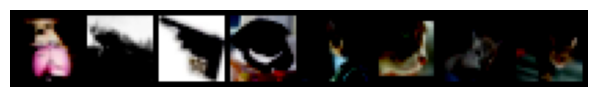

In [4]:
# Show a few images from loader
def show_samples(image_batch, N=8):
    '''
    N: number of samples
    '''
    grid = torchvision.utils.make_grid(image_batch[:N], nrow=N)
    npimg = grid.numpy()
    plt.figure(figsize=(N,1))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Preview a batch
batch = next(iter(test_loader))
image_batch, _ = batch
show_samples(image_batch)

### Masking for Image Corruption
We now write a function that can _mask_ some pixels in images. We consider both `block` and `random` masking.

In [5]:
def apply_mask(images, mask_type='block', mask_ratio=0.5):
    """
    Apply a mask to a batch of images.
    Args:
        images: Tensor of shape [B, C, H, W] == batch, channel_num, height, width
        mask_type: 'block' or 'random'
        mask_ratio: fraction of image pixels to mask
    Returns:
        masked_images: Tensor with masked pixels set to 0 of shape [B, C, H, W]
        masks: Binary mask (1 = visible, 0 = masked) of shape [B, C, H, W]
    """
    B, C, H, W = images.shape

    # We consider the same mask for all channels
    # start with all ones
    masks = torch.ones(B, 1, H, W)

    if mask_type == 'block':
        # Mask a center block (e.g., 50% area)
        block_size = int((mask_ratio * H * W) ** 0.5)
        start_h = (H - block_size) // 2
        start_w = (W - block_size) // 2
        masks[:, :, start_h:start_h+block_size, start_w:start_w+block_size] = 0
    elif mask_type == 'random':
        # Mask pixels randomly
        for i in range(B):
            num_masked = int(H * W * mask_ratio)
            indices = torch.randperm(H * W)[:num_masked]
            masks[i, 0].view(-1)[indices] = 0

    # Copy the mask in all C channels
    masks = masks.expand(-1, C, -1, -1).contiguous() # -1: keep dim as is
    # so (B,1,H,W) -> (B,C,H,W)
    # in which (at dim 1) expand from 1 to C channels

    # Apply mask to the images
    # masked_images = images.to(device) * masks
    masked_images = images * masks.to(images.device) # stays cpu; move to device in training

    return masked_images, masks


Now let's take a look at a few masked images using the `show_samples()` function.

Original:


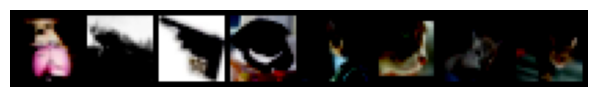

Masked:


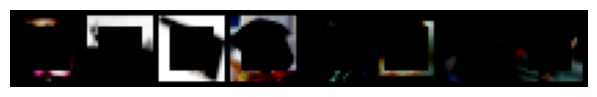

In [6]:
# Get a batch of images
images, _ = next(iter(test_loader))
# next(iter(.)) is equivalent to:
# for images, labels in test_loader:
#   # first batch
#   break

# Apply mask
masked_images, masks = apply_mask(images) # with default: mask_type='block', mask_ratio=0.5

# Preview original and masked ones
print("Original:")
show_samples(images)
print("Masked:")
show_samples(masked_images)

### Implementing AR Model
We next implement a masked CNN to learn the data distribution in AR manner. To this end, we first modify the class `nn.Conv2d` to `MaskedConv2d` which further applies masking.

In [7]:
class MaskedConv2d(nn.Conv2d):
    def __init__(self, *args, mask_type='B', **kwargs):
        super().__init__(*args, **kwargs)
        assert mask_type in ['A', 'B']
        self.register_buffer('mask', torch.ones_like(self.weight.data))
        _, _, h, w = self.weight.size()

        # add mask to the convolution

        # zero out all rows below center
        self.mask[:, :, h//2+1:, :] = 0
        # zero out right of center in the middle row
        self.mask[:, :, h//2, w//2+1:] = 0
        # type A also masks the center pixel itself (no self-connection)
        if mask_type == 'A':
            self.mask[:, :, h//2, w//2] = 0

    def forward(self, x):
        masked_weight = self.weight * self.mask
        return F.conv2d(x, masked_weight, self.bias, self.stride,
                        self.padding, self.dilation, self.groups)


Using `MaskedConv2d`, we now implement a simple Masked CNN with 3 masked convolutional layers with the first two layers being ReLU-activated. For the first layer use `mask_type = 'A'` and for the remaining `mask_type = 'B'`.

In [8]:
class MyMaskedCNN(nn.Module):
    def __init__(self, in_channels=3, hidden_channels=64, num_classes=256):
        super().__init__()
        self.num_channels = in_channels
        self.num_classes = num_classes

        self.net = nn.Sequential(
            # No softmax here — let CrossEntropyLoss handle logits

            # layer 1: type A — does not see current pixel
            MaskedConv2d(in_channels, hidden_channels, kernel_size=7, padding=3, mask_type='A'),
            nn.ReLU(),
            # layer 2: type B — can see current pixel's prior output
            MaskedConv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1, mask_type='B'),
            nn.ReLU(),
            # layer 3: output 256 logits per channel per pixel, no activation
            MaskedConv2d(hidden_channels, in_channels * num_classes, kernel_size=3, padding=1, mask_type='B'),
        )

    def forward(self, x):
        return self.net(x)  # [B, C*256, H, W]

### Training Masked CNN
We next train the masked CNN using teacher-forcing technique: in each iteration, we pass masked image (corrupted one) through the model and compare it against the true image.

In [9]:
def train_model(model, dataloader, num_epochs=30, lr=1e-3, mask_type='block', num_classes=256):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss(reduction='none') # mask-aware

    for epoch in range(num_epochs):
        total_loss = 0.0
        for images, _ in dataloader:
            images = images.to(device)  # [B, 3, H, W]
            masked_images, masks = apply_mask(images, mask_type=mask_type, mask_ratio=0.5)
            masked_images = masked_images.to(device)
            masks = masks.to(device)

            # Quantize target pixel values from (0,1) back to integer class labels (0–255)
            labels = ((images * 0.5 + 0.5) * 255).long().clamp(0, 255)  # [B, 3, H, W]

            output = model(masked_images)  # [B, 3*256, H, W]

            loss = 0.0
            for ch in range(3):
                logits = output[:, ch*num_classes:(ch+1)*num_classes, :, :]   # [B, 256, H, W]
                target_ch = labels[:, ch, :, :]                               # [B, H, W]
                mask_ch = masks[:, ch, :, :]                                  # [B, H, W]

                # compute loss only on masked pixels (mask_ch == 0)
                ch_loss = loss_fn(logits, target_ch) * (1 - mask_ch)          # [B, H, W]
                loss += ch_loss.sum() / (1 - mask_ch).sum().clamp(min=1)      # scalar

            loss = loss / 3.0

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(dataloader):.4f}")


We can now train the masked CNN.

In [10]:
model = MyMaskedCNN()
train_model(model, train_loader)

Epoch 1/30, Loss: 5.5437
Epoch 2/30, Loss: 5.5353
Epoch 3/30, Loss: 5.5173
Epoch 4/30, Loss: 5.4856
Epoch 5/30, Loss: 5.4604
Epoch 6/30, Loss: 5.4341
Epoch 7/30, Loss: 5.4057
Epoch 8/30, Loss: 5.3797
Epoch 9/30, Loss: 5.3658
Epoch 10/30, Loss: 5.3495
Epoch 11/30, Loss: 5.3362
Epoch 12/30, Loss: 5.3300
Epoch 13/30, Loss: 5.3113
Epoch 14/30, Loss: 5.3044
Epoch 15/30, Loss: 5.2942
Epoch 16/30, Loss: 5.2947
Epoch 17/30, Loss: 5.2834
Epoch 18/30, Loss: 5.2840
Epoch 19/30, Loss: 5.2644
Epoch 20/30, Loss: 5.2661
Epoch 21/30, Loss: 5.2507
Epoch 22/30, Loss: 5.2467
Epoch 23/30, Loss: 5.2319
Epoch 24/30, Loss: 5.2391
Epoch 25/30, Loss: 5.2287
Epoch 26/30, Loss: 5.2418
Epoch 27/30, Loss: 5.2199
Epoch 28/30, Loss: 5.1990
Epoch 29/30, Loss: 5.2108
Epoch 30/30, Loss: 5.1967


### Sampling and Inpainting
We now sample from the model: we pass the masked images (from test set) and autoregressively sample from it.

In [11]:
def autoregressive_sample(model, masked_images, mask, num_classes=256, visualize=True):
    model.eval()

    B, C, H, W = masked_images.shape
    masked_images = masked_images.to(device)
    mask = mask.to(device)

    sampled = masked_images.clone()

    with torch.no_grad():
        for i in range(H):
            for j in range(W):
                for ch in range(C):
                    to_fill = (mask[:, ch, i, j] == 0)
                    if to_fill.sum() == 0:
                        continue

                    out = model(sampled)                                         # [B, 3*256, H, W]
                    logits = out[:, ch*num_classes:(ch+1)*num_classes, i, j]     # [B, 256]

                    probs = F.softmax(logits, dim=1)                             # [B, 256]
                    sampled_vals = torch.multinomial(probs, 1).squeeze(1)        # [B]

                    # scale from [0,255] back to [-1,1] to match normalized image range
                    sampled_vals = sampled_vals.float() / 255.0 * 2.0 - 1.0

                    sampled[to_fill, ch, i, j] = sampled_vals[to_fill]

    if visualize:
        for i in range(min(B, 8)):
            fig, axs = plt.subplots(1, 3, figsize=(9, 3))
            axs[0].imshow(np.transpose(image_batch[i].cpu().numpy(), (1, 2, 0)))
            axs[1].imshow(np.transpose(masked_images[i].cpu().numpy(), (1, 2, 0)))
            axs[2].imshow(np.transpose(sampled[i].cpu().numpy(), (1, 2, 0)))
            for ax in axs: ax.axis('off')
            axs[0].set_title("Original")
            axs[1].set_title("Masked")
            axs[2].set_title("Sampled")
            plt.show()

    return sampled


Let us now have a few samples.

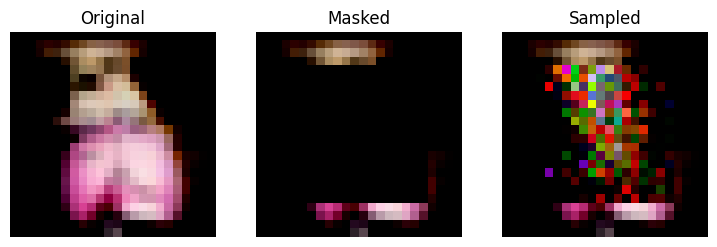

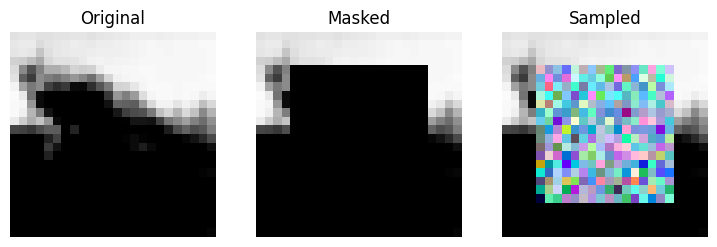

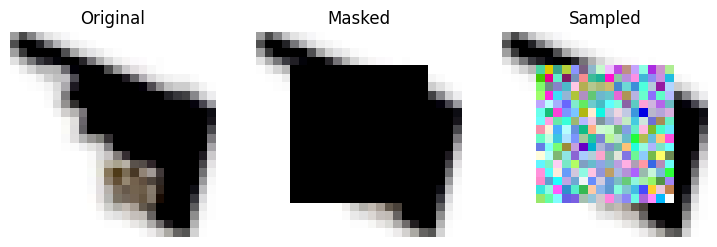

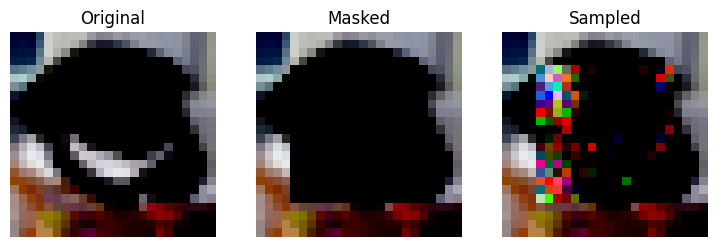

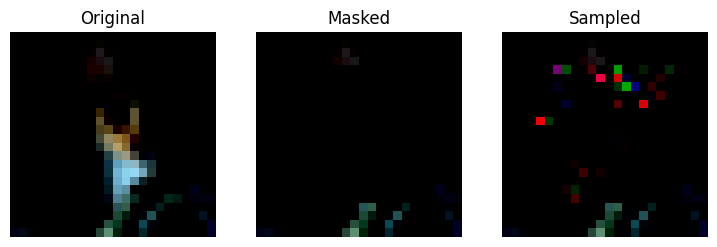

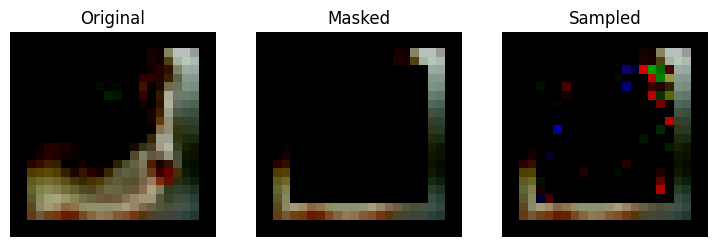

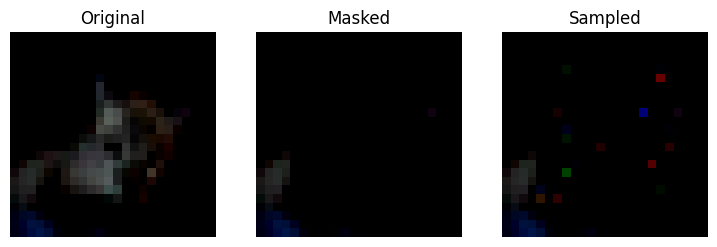

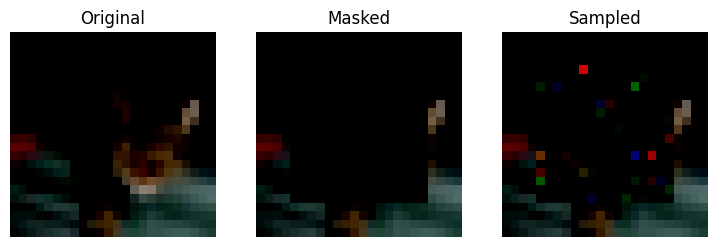

In [12]:
image_batch, _ = next(iter(test_loader))
masked_images, mask = apply_mask(image_batch, mask_type='block', mask_ratio=0.5)
sampled_images = autoregressive_sample(model, masked_images, mask, num_classes=256, visualize=True)


### Characterizing MSE and PSNR
Two evaluation metrics we can use to evaluate inpainting are MSE and PSNR. In MSE, we compute the difference between the true and reconstructed images. PSNR is defined as

$$ \mathrm{PSNR} = \frac{x_{\max}^2}{\mathrm{MSE}} $$

for some maximum value $x_{\max}$. PSNR is typically reported in dB. We now implement these two metrics.

In [13]:
# Compute the MSE
def compute_mse(original, reconstructed, mask):
    """
    Computes MSE only over masked regions.
    """
    diff = (original - reconstructed) ** 2
    masked_diff = diff * (1 - mask)  # Only consider masked regions
    mse = masked_diff.sum() / (1 - mask).sum().clamp(min=1)  # Average over masked pixels
    return mse.item()

# Compute PSNR
def compute_psnr(original, reconstructed, mask, max_val=1.0):
    """
    Computes PSNR over masked regions.
    """
    mse = compute_mse(original, reconstructed, mask)
    if mse == 0:
        return float('inf')
    return (max_val ** 2) / mse
    # return 20 * math.log10(max_val / math.sqrt(mse))

We next implement a function that sketches the performance of the trained model against the `mask_ratio`, i.e., the fraction of pixels missing.

In [14]:
def evaluate_model_vs_mask_ratio(model, dataloader, ratios=[0.1, 0.2, 0.4, 0.6, 0.8]):
    model.eval()
    psnrs = []
    mses = []

    with torch.no_grad():
        for ratio in ratios:
            total_psnr = 0.0
            total_mse = 0.0
            num_batches = 0

            for images, _ in dataloader:
                images = images.to(device)

                # Mask images with the given ratios
                masked_images, masks = apply_mask(images, mask_type='block', mask_ratio=ratio)

                # move to device
                masked_images = masked_images.to(device)
                masks = masks.to(device)

                # reconstruct by AR sampling
                reconstructed = autoregressive_sample(model, masked_images, masks, num_classes=256, visualize=False)

                # compute MSE
                batch_mse = compute_mse(images, reconstructed, masks)
                total_mse += batch_mse

                # compute PSNR
                batch_psnr = compute_psnr(images, reconstructed, masks)
                total_psnr += batch_psnr

                # update batch counter
                num_batches += 1

                # Optional: limit for speed
                if num_batches == 10:
                    break

            mses.append(total_mse / num_batches)
            psnrs.append(total_psnr / num_batches)
    return ratios, mses, psnrs


Let us call `evaluate_model_vs_mask_ratio` and plot it.

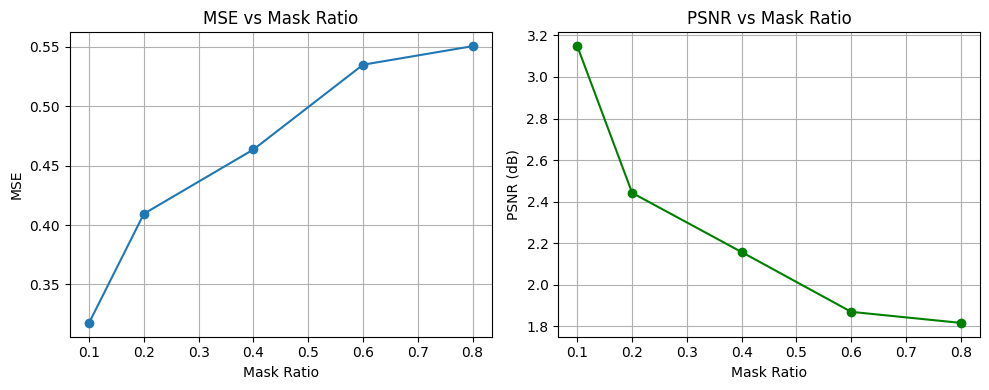

In [15]:
ratios, mses, psnrs = evaluate_model_vs_mask_ratio(model, test_loader, ratios=[0.1, 0.2, 0.4, 0.6, 0.8])

# Plot MSE vs ratio
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(ratios, mses, marker='o')
plt.xlabel('Mask Ratio')
plt.ylabel('MSE')
plt.title('MSE vs Mask Ratio')
plt.grid(True)

# Plot PSNR vs mask ratio
plt.subplot(1, 2, 2)
plt.plot(ratios, psnrs, marker='o', color='green')
plt.xlabel('Mask Ratio')
plt.ylabel('PSNR (dB)')
plt.title('PSNR vs Mask Ratio')
plt.grid(True)

# show plots
plt.tight_layout()
plt.show()


### What do you conclude from the above figures?

When the mask ratio increases, MSE increases while PSNR decreases. This is consistent with the fact that when more pixels are missing from an image, it becomes harder for the model to reconstruct the image accurately.